In [1]:
import pandas as pd

In [4]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [6]:
df = pd.read_csv('train.csv')

In [7]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


<Axes: >

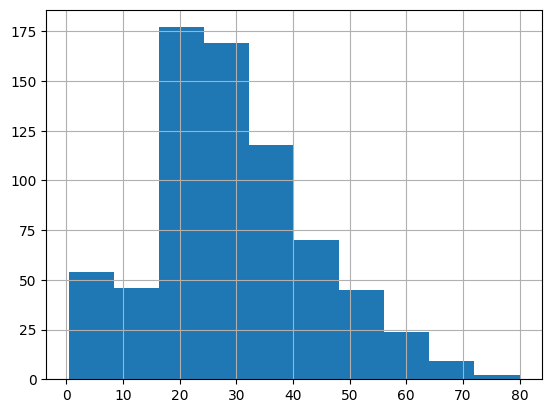

In [8]:
df["Age"].hist()

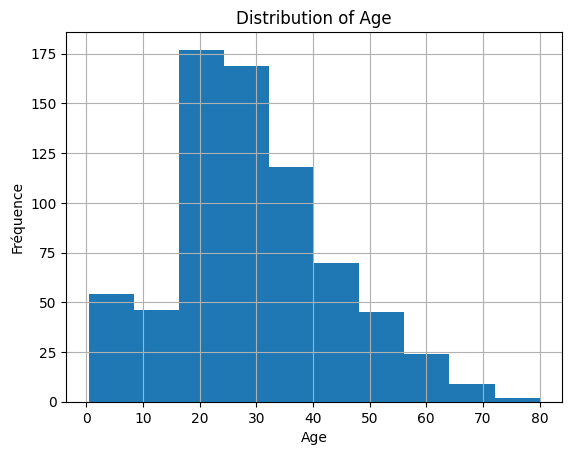

In [10]:
df['Age'].hist()
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Fréquence")
plt.show()

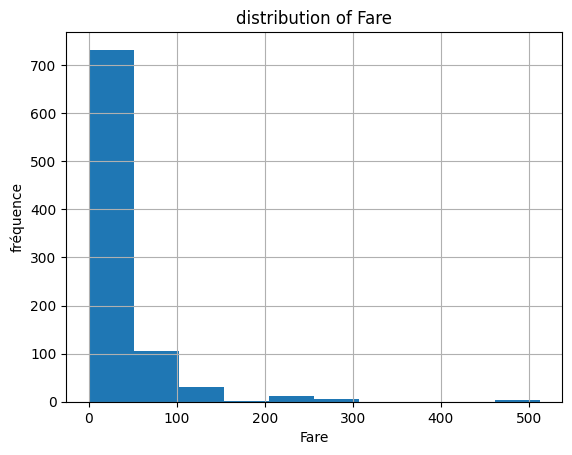

In [12]:
df["Fare"].hist()
plt.title('distribution of Fare')
plt.xlabel("Fare")
plt.ylabel('fréquence')
plt.show()

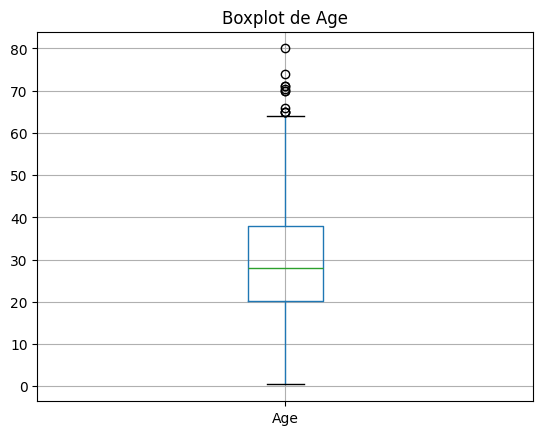

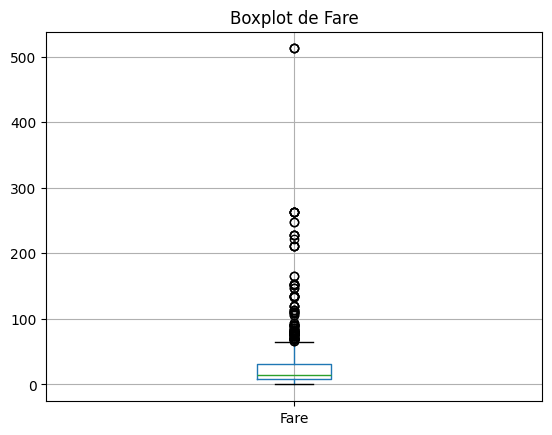

In [18]:
df.boxplot(column=['Age'])
plt.title("Boxplot de Age")
plt.show()

df.boxplot(column=['Fare'])
plt.title("Boxplot de Fare")
plt.show()

In [13]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

In [14]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [15]:
print("Limite inférieure :", lower_bound)
print("Limite supérieure :", upper_bound)

Limite inférieure : -26.724
Limite supérieure : 65.6344


In [16]:
outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]
print("Nombre d'outliers sur Fare :", len(outliers))

Nombre d'outliers sur Fare : 116


In [19]:
df_capped = df.copy()

upper_cap = df_capped['Fare'].quantile(0.98)
lower_cap = df_capped['Fare'].quantile(0.02)

df_capped['Fare'] = df_capped['Fare'].clip(lower=lower_cap, upper=upper_cap)